In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)


In [ ]:
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})
df['has_kids'] = (df.children > 0).astype(int)
df.dropna(inplace=True)
df.reset_index(inplace=True, drop=True)
df.head()


,age,sex,bmi,children,smoker,region,charges,smoker_encoded,has_kids
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


In [ ]:
def interpret_interaction(model, main_var, cat_var, cat_label):
    params = model.params
    intercept = params['Intercept']
    main_coef = params[main_var]
    cat_key = [k for k in params.index if cat_var in k and ':' not in k][0]
    inter_key = [k for k in params.index if ':' in k][0]

    cat_coef = params[cat_key]
    inter_coef = params[inter_key]

    print(f"Group = baseline (not {cat_label}):")
    print(
        f"  {model.model.endog_names} = {intercept:.2f} + {main_coef:.2f} * {main_var}")
    print()
    print(f"Group = {cat_label}:")
    new_intercept = intercept + cat_coef
    new_slope = main_coef + inter_coef
    print(
        f"  {model.model.endog_names} = {new_intercept:.2f} + {new_slope:.2f} * {main_var}")
    print()
    print(f"Interpretation: each unit of {main_var} changes the outcome by "
          f"{main_coef:.2f} in the baseline group, vs {new_slope:.2f} "
          f"in the {cat_label} group -- a difference of {inter_coef:.2f} per unit.")


In [ ]:
# Subset X and y variables
df_X = df[["smoker", "bmi", 'age']]
df_y = df[["charges"]]


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
# Create training data sets and holdout (testing) data sets
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y,
                                                    test_size=0.3, random_state=42)


In [ ]:
# Write out OLS formula as a string
ols_formula = "charges ~ bmi * C(smoker) + age"


In [ ]:
# Import ols() function from statsmodels package
from statsmodels.formula.api import ols


In [ ]:
# Create OLS dataframe
ols_data = pd.concat([X_train, y_train], axis=1)

# Create OLS object and fit the model
OLS = ols(formula=ols_formula, data=ols_data)
model = OLS.fit()


In [ ]:
# Get model results
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     1116.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:01:48   Log-Likelihood:                -9305.5
No. Observations:                 936   AIC:                         1.862e+04
Df Residuals:                     931   BIC:                         1.865e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -2625.1297   1033.628     -2.540      0.011   -4653.641    -596.618
C(smoker)[T.yes]     -2.061e+04   2073.536     -9.942      0.000   -2.47e+04   -1.65e+04
bmi                     14.8209     31.264      0.474      0.636     -46.536      76.178
bmi:C(smoker)[T.yes]  1451.5881     66.665     21.774      0.000    1320.756    1582.420
age                    271.0340     11.757     23.053      0.000     247.961     294.107
==============================================================================
Omnibus:                      481.617   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2605.818
Skew:                           2.403   Prob(JB):                         0.00
Kurtosis:                       9.612   Cond. No.                         667.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
interpret_interaction(model, 'bmi', 'smoker', 'smoker')


Group = baseline (not smoker):
  charges = -2625.13 + 14.82 * bmi

Group = smoker:
  charges = -23239.33 + 1466.41 * bmi

Interpretation: each unit of bmi changes the outcome by 14.82 in the baseline group, vs 1466.41 in the smoker group -- a difference of 1451.59 per unit.


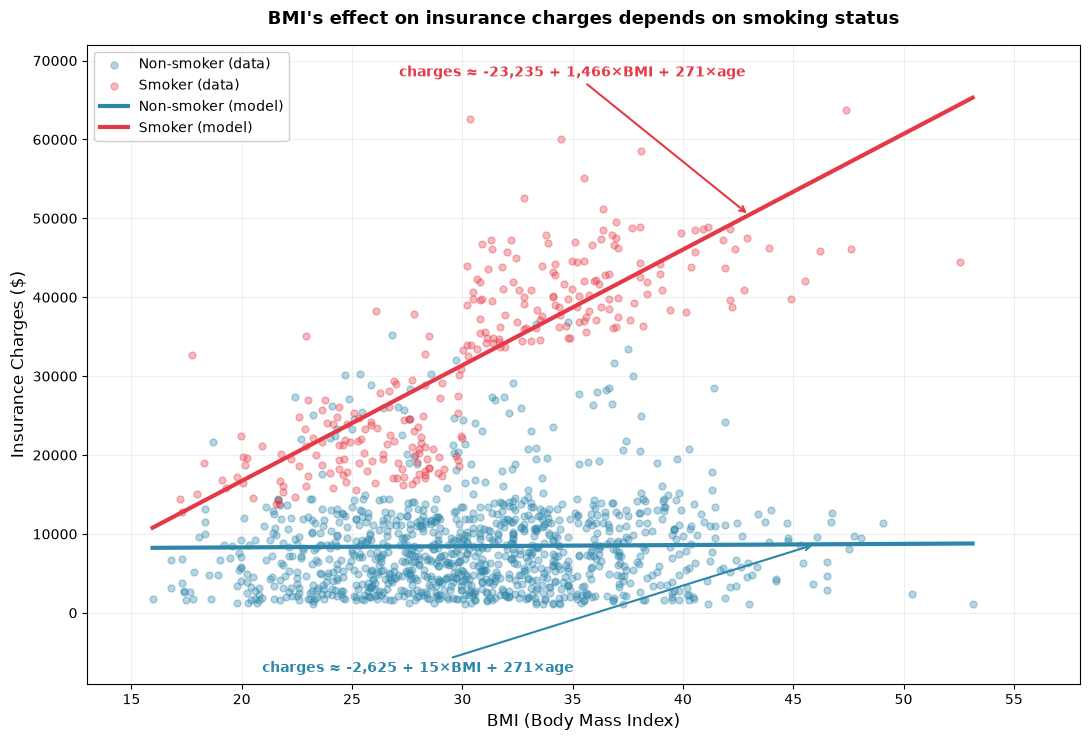

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = {'no': '#2E86AB', 'yes': '#E63946'}
labels = {'no': 'Non-smoker', 'yes': 'Smoker'}

fig, ax = plt.subplots(figsize=(11, 7.5))

for smoker_status in ['no', 'yes']:
    subset = df[df['smoker'] == smoker_status]
    ax.scatter(subset['bmi'], subset['charges'],
               alpha=0.35, s=25, color=colors[smoker_status],
               label=f"{labels[smoker_status]} (data)")

avg_age = df['age'].mean()
bmi_range = np.linspace(df['bmi'].min(), df['bmi'].max(), 100)

pred_df_no = pd.DataFrame({'bmi': bmi_range, 'smoker': 'no', 'age': avg_age})
pred_df_yes = pd.DataFrame({'bmi': bmi_range, 'smoker': 'yes', 'age': avg_age})

pred_no = model.predict(pred_df_no)
pred_yes = model.predict(pred_df_yes)

ax.plot(bmi_range, pred_no, color=colors['no'],
        linewidth=3, label='Non-smoker (model)')
ax.plot(bmi_range, pred_yes,
        color=colors['yes'], linewidth=3, label='Smoker (model)')

ax.set_xlabel('BMI (Body Mass Index)', fontsize=12)
ax.set_ylabel('Insurance Charges ($)', fontsize=12)
ax.set_title("BMI's effect on insurance charges depends on smoking status",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.2)
ax.set_ylim(-9000, 72000)
ax.set_xlim(13, 58)

ax.annotate('charges ≈ -23,235 + 1,466×BMI + 271×age',
            xy=(43, pred_yes[np.argmin(np.abs(bmi_range-43))]),
            xytext=(35, 68000),
            fontsize=10, color=colors['yes'], fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=colors['yes'], lw=1.5))

ax.annotate('charges ≈ -2,625 + 15×BMI + 271×age',
            xy=(46, pred_no[np.argmin(np.abs(bmi_range-46))]),
            xytext=(28, -7500),
            fontsize=10, color=colors['no'], fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=colors['no'], lw=1.5))

plt.tight_layout()
plt.savefig('bmi_smoker_interaction.png', dpi=200, bbox_inches='tight')
plt.show()
